In [1]:
import zarr
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def plot_spectrogram(samples, sample_rate, nfft=512, title=None, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.specgram(samples, NFFT=nfft, Fs=sample_rate,
                noverlap=nfft // 2, scale='dB', mode='psd')
    ax.set_title(title or "Spectrogram")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Frequency [Hz]")
    plt.show()

In [3]:
# 🔍 Load Zarr
zarr_path = "/home/sigence/selfRF/datasets/NARROWBAND_ZARR/data.zarr"
z = zarr.open(zarr_path, mode="r")

In [4]:
# 🔍 Get metadata
metadata = z.attrs.asdict()
sample_rate = metadata['0'][0].get("sample_rate", 81920000)  # fallback default

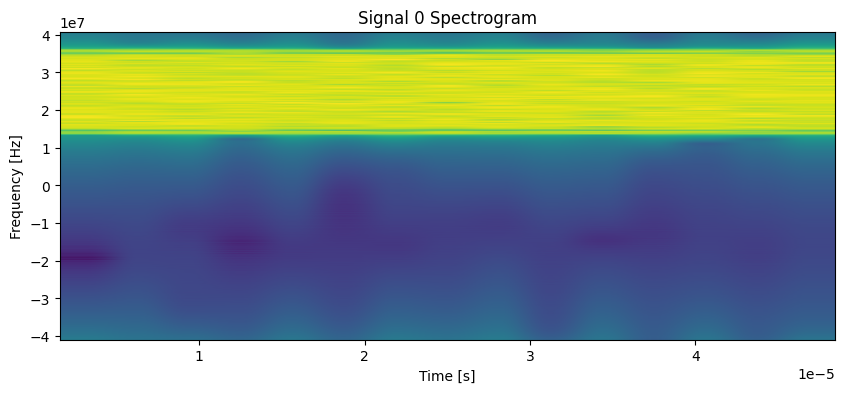

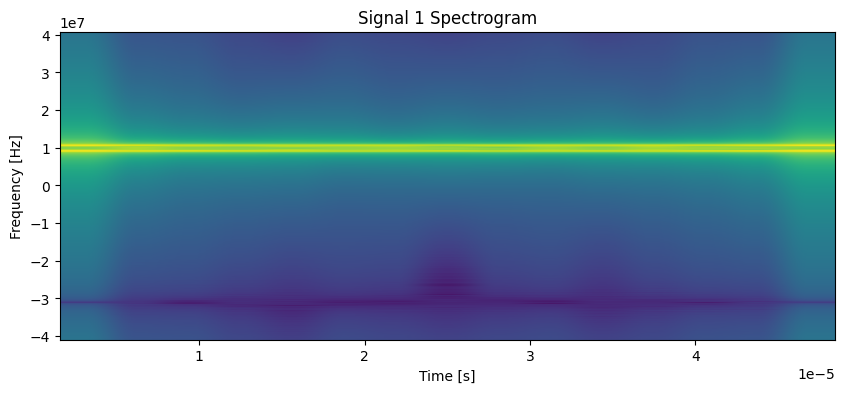

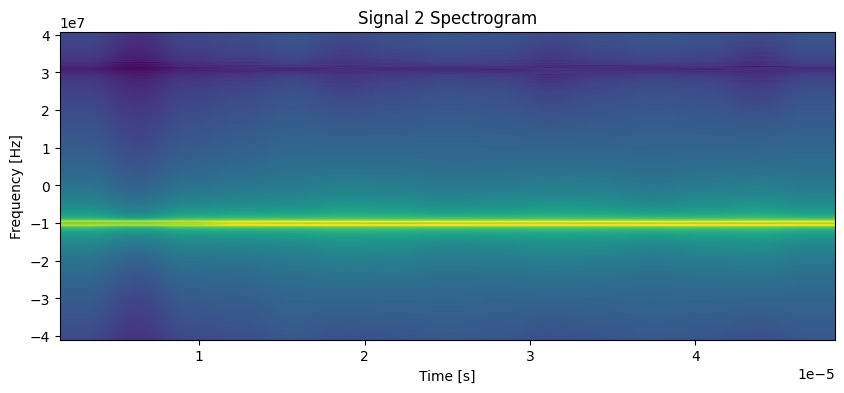

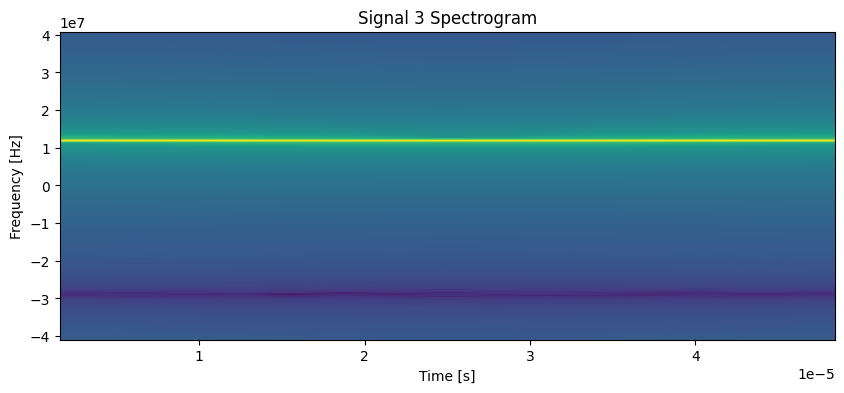

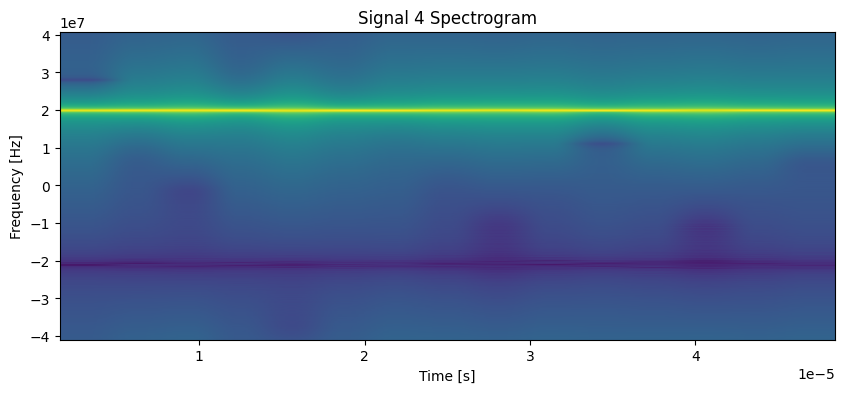

/home/sigence/selfRF/xcit_venv/lib/python3.10/site-packages/matplotlib/axes/_axes.py:8264: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


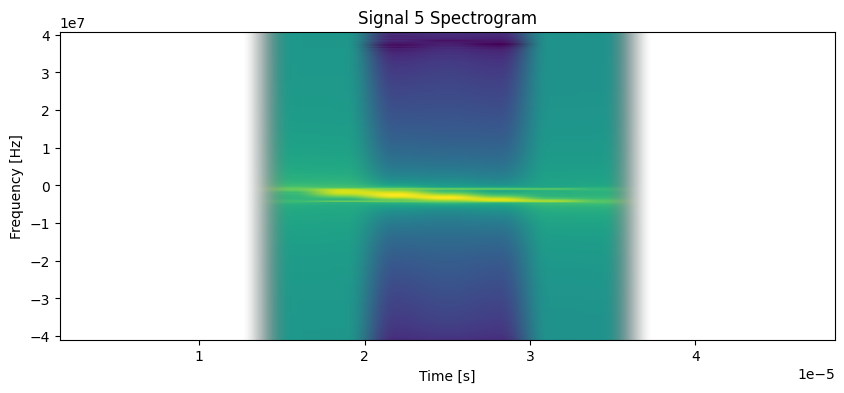

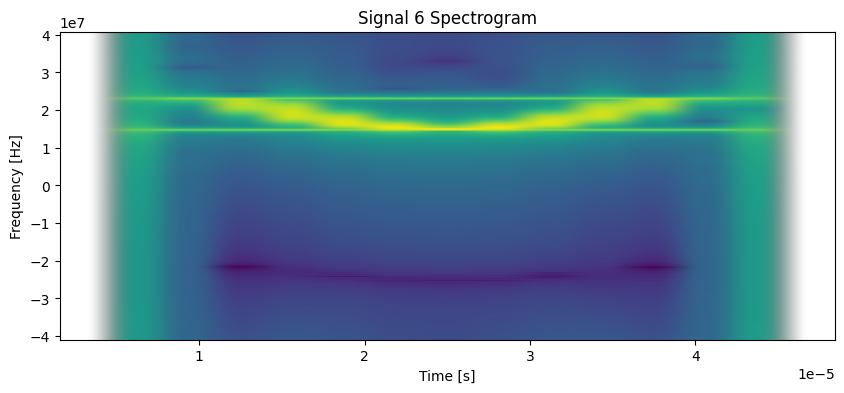

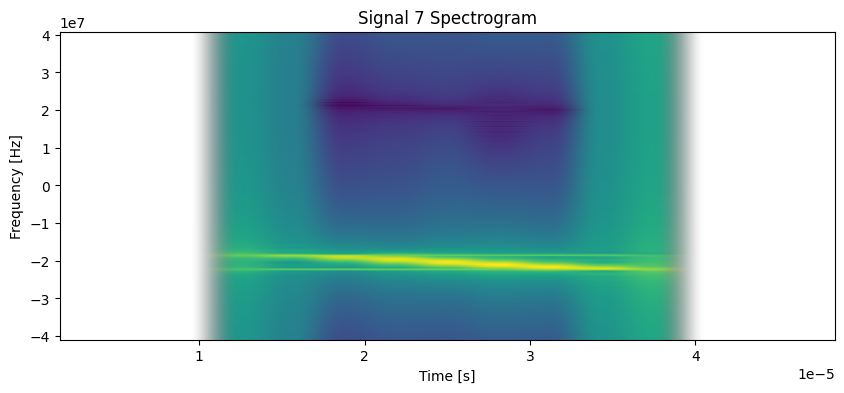

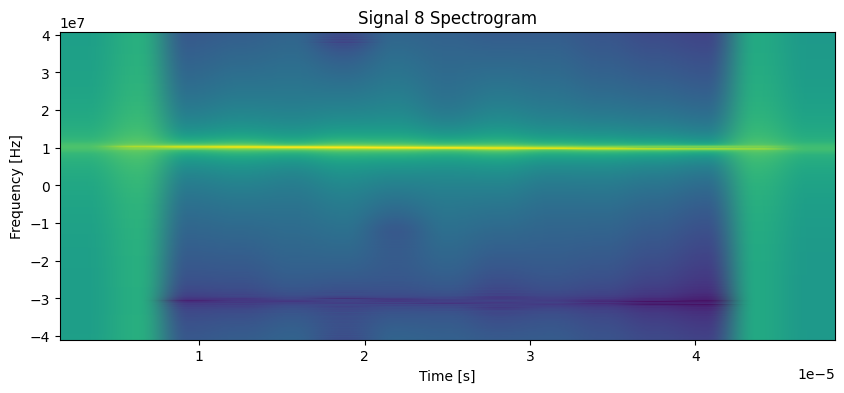

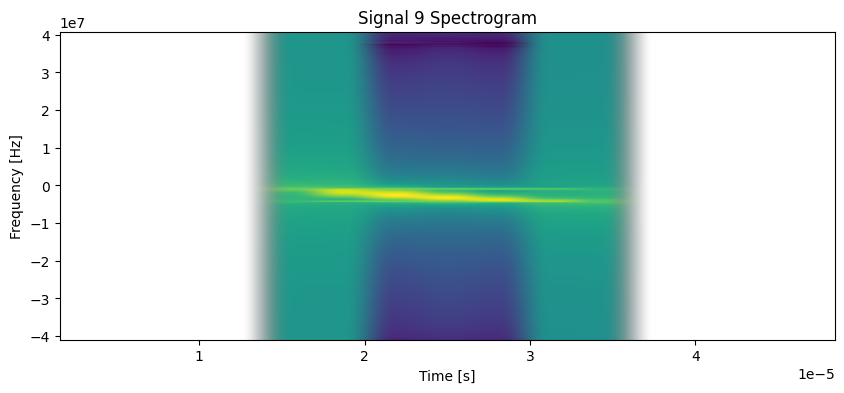

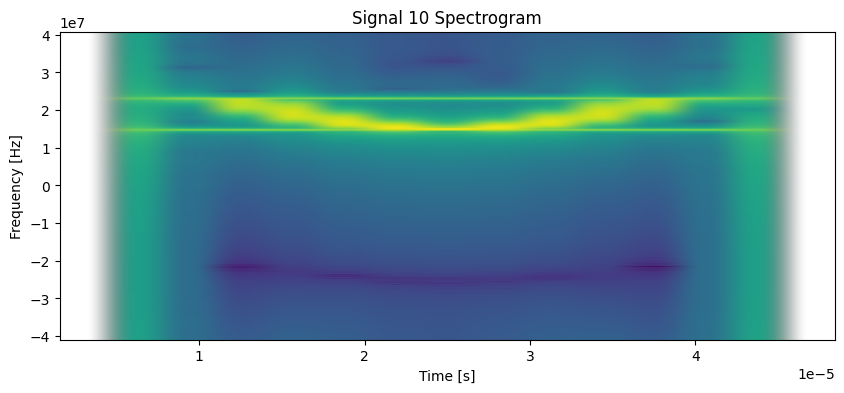

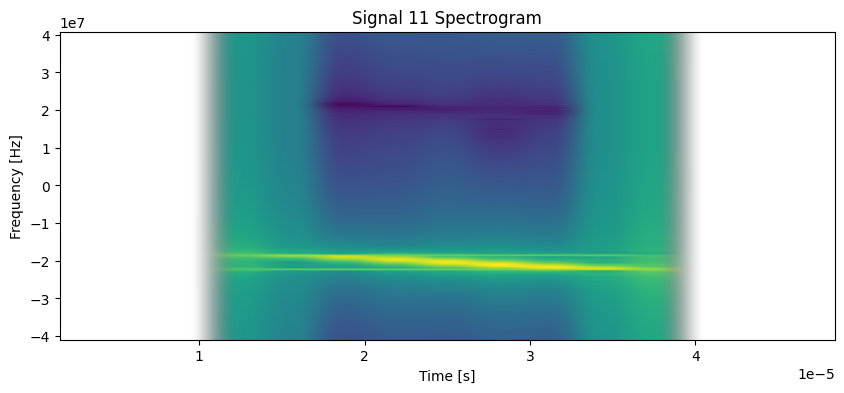

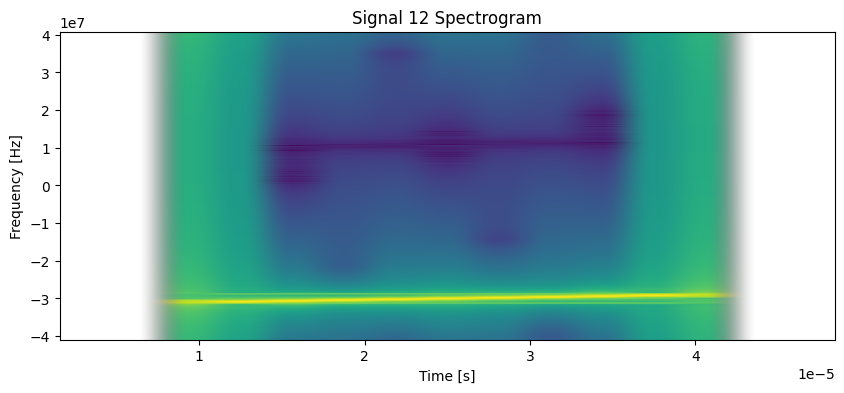

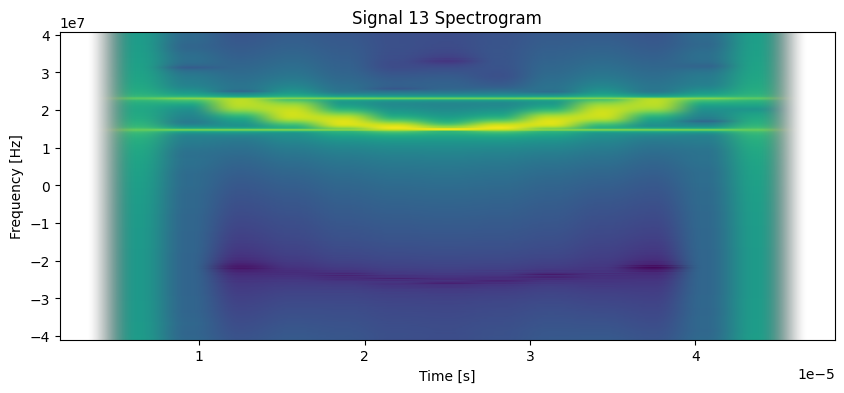

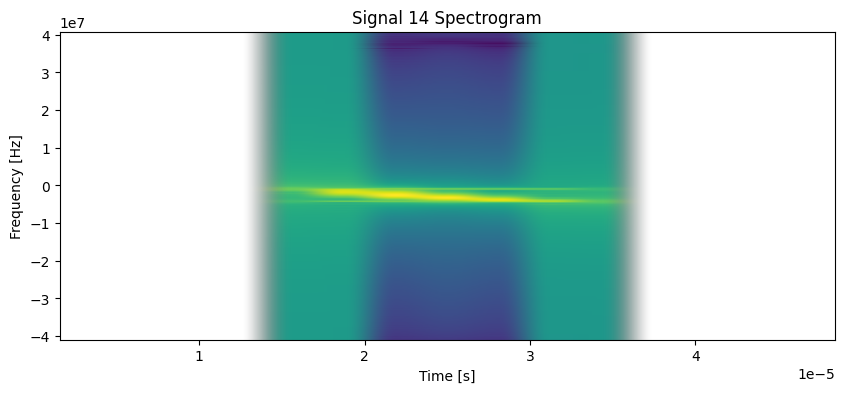

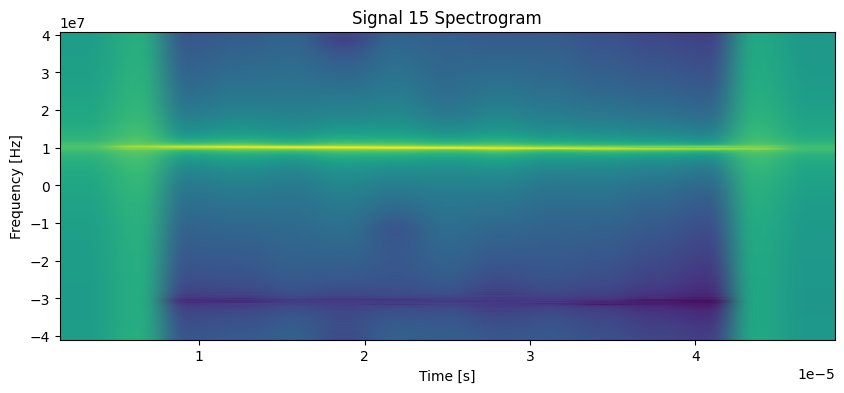

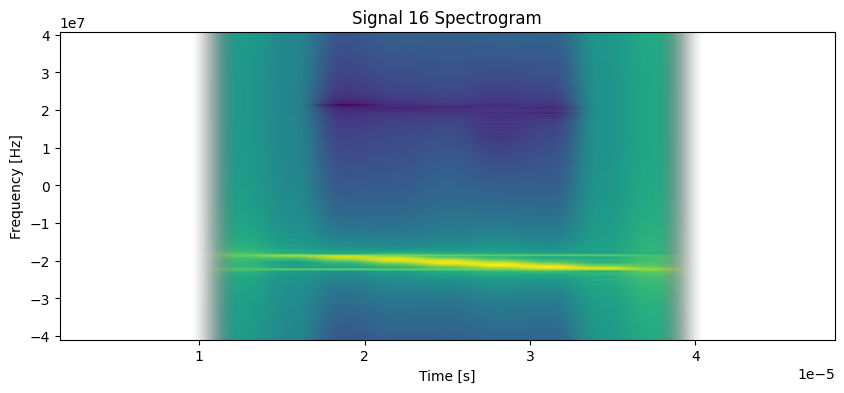

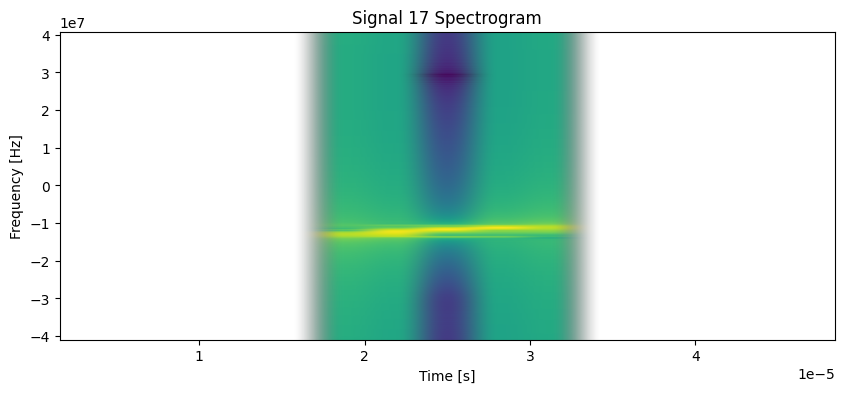

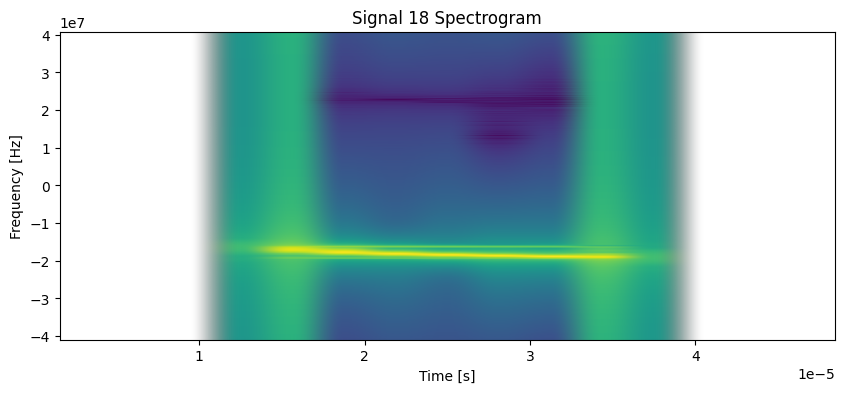

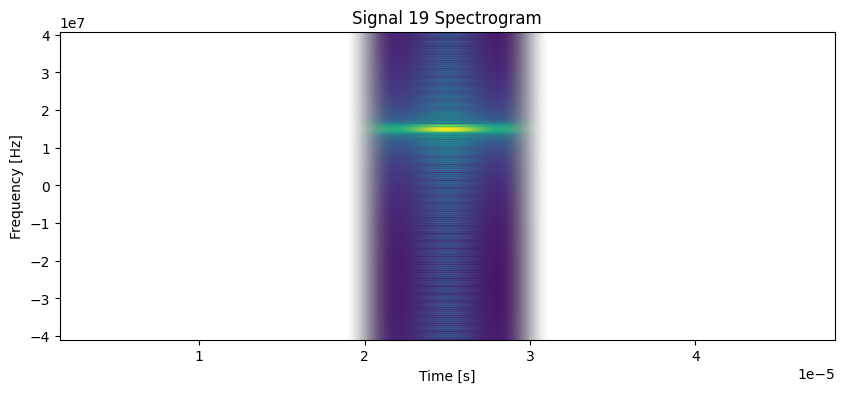

In [5]:
# 🎨 Plot first 10 signals
for i in range(min(20, len(z))):
    samples = z[i]
    plot_spectrogram(
        samples,
        sample_rate,
        title=f"Signal {i} Spectrogram",
    )

In [6]:
print("Min:", samples.min(), "Max:", samples.max(),
      "Mean abs:", np.mean(np.abs(samples)))

Min: (-0.00030407973-7.3962824e-06j) Max: (0.00029545132-7.264594e-05j) Mean abs: 7.98877e-06
